100.0%
100.0%
100.0%
100.0%


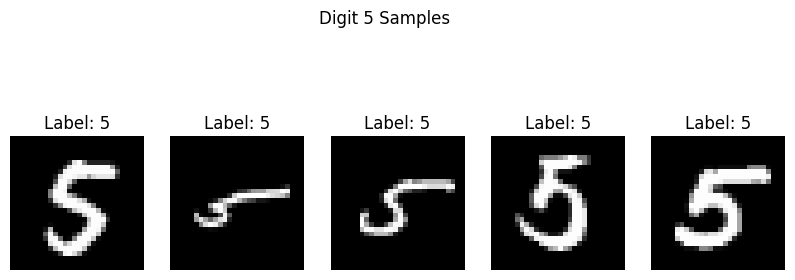


开始训练多分类模型...
Epoch [1/5], Batch [100/938], Loss: 0.7622
Epoch [1/5], Batch [200/938], Loss: 0.2601
Epoch [1/5], Batch [300/938], Loss: 0.1691
Epoch [1/5], Batch [400/938], Loss: 0.1454
Epoch [1/5], Batch [500/938], Loss: 0.1489
Epoch [1/5], Batch [600/938], Loss: 0.1152
Epoch [1/5], Batch [700/938], Loss: 0.1121
Epoch [1/5], Batch [800/938], Loss: 0.1153
Epoch [1/5], Batch [900/938], Loss: 0.0943
Epoch [2/5], Batch [100/938], Loss: 0.0846
Epoch [2/5], Batch [200/938], Loss: 0.0786
Epoch [2/5], Batch [300/938], Loss: 0.0833
Epoch [2/5], Batch [400/938], Loss: 0.0730
Epoch [2/5], Batch [500/938], Loss: 0.0766
Epoch [2/5], Batch [600/938], Loss: 0.0795
Epoch [2/5], Batch [700/938], Loss: 0.0756
Epoch [2/5], Batch [800/938], Loss: 0.0753
Epoch [2/5], Batch [900/938], Loss: 0.0759
Epoch [3/5], Batch [100/938], Loss: 0.0580
Epoch [3/5], Batch [200/938], Loss: 0.0765
Epoch [3/5], Batch [300/938], Loss: 0.0613
Epoch [3/5], Batch [400/938], Loss: 0.0638
Epoch [3/5], Batch [500/938], Loss: 0.05

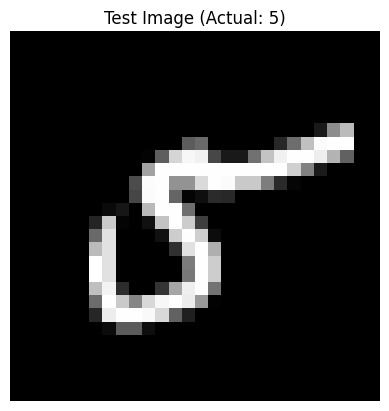

RuntimeError: Input type (double) and bias type (float) should be the same

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
from sklearn.model_selection import train_test_split

# 设置随机种子，保证结果可复现
torch.manual_seed(42)

# 数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),  # 转换为Tensor
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST数据集的均值和标准差
])

# 加载MNIST数据集
full_train_dataset = datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

full_test_dataset = datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

# 定义针对特定数字的二分类模型
class SpecificDigitClassifier(nn.Module):
    def __init__(self):
        super(SpecificDigitClassifier, self).__init__()
        # 卷积层
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        # 池化层
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # 全连接层
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 1)  # 二分类输出（是/不是指定数字）
        # 激活函数和dropout
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        # 卷积层1 + 激活 + 池化
        x = self.pool(self.relu(self.conv1(x)))
        # 卷积层2 + 激活 + 池化
        x = self.pool(self.relu(self.conv2(x)))
        # 展平
        x = x.view(-1, 64 * 7 * 7)
        # 全连接层1 + 激活 + dropout
        x = self.dropout(self.relu(self.fc1(x)))
        # 全连接层2（输出层）+ sigmoid激活
        x = self.sigmoid(self.fc2(x))
        return x

# 定义多分类模型（用于识别所有数字）
class MNISTClassifier(nn.Module):
    def __init__(self):
        super(MNISTClassifier, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)  # 10个类别（0-9）
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# 为特定数字创建二分类数据集
def create_binary_dataset(dataset, target_digit):
    # 找出所有是目标数字和不是目标数字的索引
    target_indices = [i for i, (_, label) in enumerate(dataset) if label == target_digit]
    non_target_indices = [i for i, (_, label) in enumerate(dataset) if label != target_digit]
    
    # 平衡数据集 - 选取与目标数字数量相同的非目标数字样本
    num_samples = min(len(target_indices), len(non_target_indices))
    selected_non_target = np.random.choice(non_target_indices, num_samples, replace=False)
    
    # 合并索引并创建标签
    all_indices = np.concatenate([target_indices[:num_samples], selected_non_target])
    labels = np.concatenate([np.ones(num_samples), np.zeros(num_samples)])
    
    # 打乱顺序
    shuffle_indices = np.random.permutation(len(all_indices))
    all_indices = all_indices[shuffle_indices]
    labels = labels[shuffle_indices]
    
    # 创建子集
    subset = Subset(dataset, all_indices)
    
    return subset, labels

# 训练特定数字的二分类模型
def train_specific_digit_model(target_digit, num_epochs=5):
    model = SpecificDigitClassifier()
    criterion = nn.BCELoss()  # 二分类交叉熵损失
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # 创建训练和测试数据集
    train_subset, train_labels = create_binary_dataset(full_train_dataset, target_digit)
    test_subset, test_labels = create_binary_dataset(full_test_dataset, target_digit)
    
    # 创建数据加载器
    train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=1000, shuffle=False)
    
    # 训练模型
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for batch_idx, (data, _) in enumerate(train_loader):
            # 获取真实标签（是/不是目标数字）
            batch_indices = train_loader.dataset.indices[batch_idx*64 : (batch_idx+1)*64]
            labels = torch.tensor([1.0 if full_train_dataset[i][1] == target_digit else 0.0 
                                  for i in batch_indices], dtype=torch.float32).view(-1, 1)
            
            # 清零梯度
            optimizer.zero_grad()
            
            # 前向传播
            outputs = model(data)
            loss = criterion(outputs, labels)
            
            # 反向传播和优化
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            # 每100个批次打印一次信息
            if batch_idx % 100 == 99:
                print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {running_loss/100:.4f}')
                running_loss = 0.0
    
    # 保存模型
    model_path = f'mnist_digit_{target_digit}_model.pth'
    torch.save(model.state_dict(), model_path)
    print(f"特定数字 {target_digit} 的模型已保存为 '{model_path}'")
    
    # 测试模型
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, _ in test_loader:
            batch_indices = test_loader.dataset.indices[total : total+len(data)]
            labels = torch.tensor([1.0 if full_test_dataset[i][1] == target_digit else 0.0 
                                  for i in batch_indices], dtype=torch.float32).view(-1, 1)
            
            outputs = model(data)
            predicted = (outputs > 0.5).float()  # 大于0.5视为目标数字
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    print(f'特定数字 {target_digit} 的模型在测试集上的准确率: {accuracy:.2f}%')
    
    return model, accuracy

# 训练多分类模型
def train_multiclass_model(num_epochs=5):
    model = MNISTClassifier()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # 创建数据加载器
    train_loader = DataLoader(full_train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(full_test_dataset, batch_size=1000, shuffle=False)
    
    # 训练模型
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            if batch_idx % 100 == 99:
                print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {running_loss/100:.4f}')
                running_loss = 0.0
    
    # 保存模型
    torch.save(model.state_dict(), 'mnist_multiclass_model.pth')
    print("多分类模型已保存为 'mnist_multiclass_model.pth'")
    
    # 测试模型
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    accuracy = 100 * correct / total
    print(f'多分类模型在测试集上的准确率: {accuracy:.2f}%')
    
    return model, accuracy

# 预测图像是否为特定数字
def predict_specific_digit(image_path, target_digit):
    # 加载模型
    model = SpecificDigitClassifier()
    model_path = f'mnist_digit_{target_digit}_model.pth'
    if not os.path.exists(model_path):
        print(f"未找到数字 {target_digit} 的模型，正在训练...")
        model, _ = train_specific_digit_model(target_digit)
    else:
        model.load_state_dict(torch.load(model_path))
    
    model.eval()
    
    # 加载并预处理图像
    image = Image.open(image_path).convert('L')  # 转换为灰度图
    image = image.resize((28, 28))  # 调整为MNIST图像大小
    image = np.array(image)
    image = 255 - image  # 反转颜色（MNIST背景是黑色，数字是白色）
    image = image / 255.0  # 归一化
    
    # 转换为Tensor并添加批次维度
    transform = transforms.ToTensor()
    image_tensor = transform(image).unsqueeze(0)
    
    # 预测
    with torch.no_grad():
        output = model(image_tensor)
        probability = output.item()
        is_target = probability > 0.5
    
    return is_target, probability

# 预测图像是哪个数字（0-9）
def predict_digit(image_path):
    # 加载模型
    model = MNISTClassifier()
    model_path = 'mnist_multiclass_model.pth'
    if not os.path.exists(model_path):
        print("未找到多分类模型，正在训练...")
        model, _ = train_multiclass_model()
    else:
        model.load_state_dict(torch.load(model_path))
    
    model.eval()
    
    # 加载并预处理图像
    image = Image.open(image_path).convert('L')
    image = image.resize((28, 28))
    image = np.array(image)
    image = 255 - image
    image = image / 255.0
    
    transform = transforms.ToTensor()
    image_tensor = transform(image).unsqueeze(0)
    
    # 预测
    with torch.no_grad():
        outputs = model(image_tensor)
        _, predicted = torch.max(outputs.data, 1)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence = probabilities[0][predicted.item()].item() * 100
    
    return predicted.item(), confidence

# 显示特定数字的样本
def show_digit_samples(target_digit, num_samples=5):
    # 找出数据集中所有是目标数字的样本
    target_indices = [i for i, (_, label) in enumerate(full_train_dataset) if label == target_digit]
    selected_indices = np.random.choice(target_indices, min(num_samples, len(target_indices)), replace=False)
    
    # 显示图像
    plt.figure(figsize=(10, 4))
    for i, idx in enumerate(selected_indices):
        image, label = full_train_dataset[idx]
        plt.subplot(1, num_samples, i+1)
        plt.imshow(image.numpy().squeeze(), cmap='gray')
        plt.title(f'Label: {label}')
        plt.axis('off')
    plt.suptitle(f'Digit {target_digit} Samples')
    plt.show()

if __name__ == '__main__':
    # 选择要识别的特定数字（0-9）
    target_digit = 5  # 可以修改为任何0-9之间的数字
    
    # 显示该数字的样本
    show_digit_samples(target_digit)
    
    # 训练多分类模型（如果不存在）
    if not os.path.exists('mnist_multiclass_model.pth'):
        print("\n开始训练多分类模型...")
        train_multiclass_model(num_epochs=5)
    else:
        print("\n多分类模型已存在，跳过训练")
    
    # 训练特定数字的模型（如果不存在）
    specific_model_path = f'mnist_digit_{target_digit}_model.pth'
    if not os.path.exists(specific_model_path):
        print(f"\n开始训练特定数字 {target_digit} 的模型...")
        train_specific_digit_model(target_digit, num_epochs=5)
    else:
        print(f"\n特定数字 {target_digit} 的模型已存在，跳过训练")
    
    # 使用测试集中的一个样本进行演示
    # 随机选择一个目标数字的样本
    target_indices = [i for i, (_, label) in enumerate(full_test_dataset) if label == target_digit]
    sample_idx = np.random.choice(target_indices)
    test_image, test_label = full_test_dataset[sample_idx]
    
    # 保存测试图像
    test_image_np = test_image.numpy().squeeze() * 0.3081 + 0.1307  # 反归一化
    test_image_np = (test_image_np * 255).astype(np.uint8)
    test_image_path = f'test_digit_{target_digit}.png'
    Image.fromarray(test_image_np).save(test_image_path)
    
    # 显示测试图像
    plt.imshow(test_image.numpy().squeeze(), cmap='gray')
    plt.title(f'Test Image (Actual: {test_label})')
    plt.axis('off')
    plt.show()
    
    # 预测是否为特定数字
    is_target, probability = predict_specific_digit(test_image_path, target_digit)
    print(f"\n预测结果：这{'' if is_target else '不'}是数字 {target_digit}")
    print(f"置信度：{probability:.2%}")
    
    # 多分类预测
    digit, confidence = predict_digit(test_image_path)
    print(f"\n多分类预测结果：这是数字 {digit}")
    print(f"置信度：{confidence:.2f}%")


findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

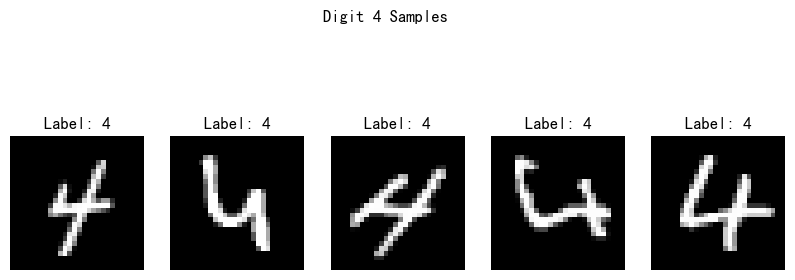


多分类模型已存在，跳过训练，正在计算混淆矩阵...


findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

多分类混淆矩阵已保存为 'multiclass_confusion_matrix.png'


findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: 

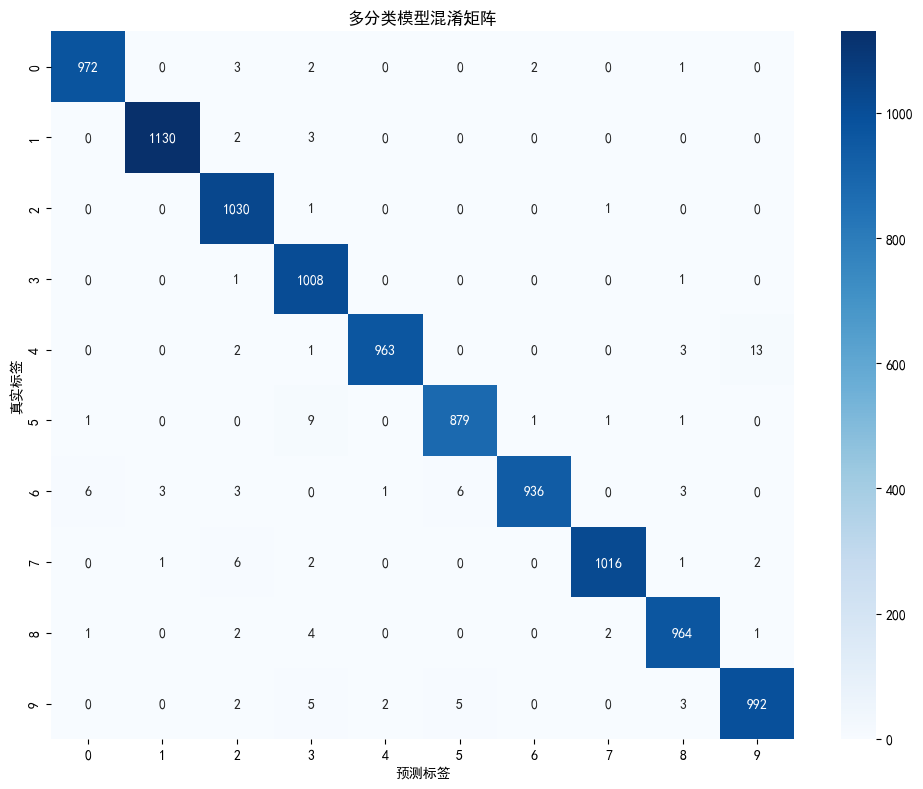

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.98      1.00      0.99      1032
           3       0.97      1.00      0.99      1010
           4       1.00      0.98      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


开始训练特定数字 4 的模型...
Epoch [1/5], Batch [100/183], Loss: 0.6952
Epoch [2/5], Batch [100/183], Loss: 0.6933
Epoch [3/5], Batch [100/183], Loss: 0.6933
Epoch [4/5], Batch [100/183], Loss: 0.6932
Epoch [5/5], Batch [100/183], Loss: 0.6933
特定数字 4 

TypeError: unsupported format string passed to numpy.ndarray.__format__

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 设置随机种子，保证结果可复现
torch.manual_seed(42)

# 数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),  # 转换为Tensor
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST数据集的均值和标准差
])

# 加载MNIST数据集
full_train_dataset = datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

full_test_dataset = datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

# 定义针对特定数字的二分类模型
class SpecificDigitClassifier(nn.Module):
    def __init__(self):
        super(SpecificDigitClassifier, self).__init__()
        # 卷积层
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        # 池化层
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # 全连接层
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 1)  # 二分类输出（是/不是指定数字）
        # 激活函数和dropout
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        # 卷积层1 + 激活 + 池化
        x = self.pool(self.relu(self.conv1(x)))
        # 卷积层2 + 激活 + 池化
        x = self.pool(self.relu(self.conv2(x)))
        # 展平
        x = x.view(-1, 64 * 7 * 7)
        # 全连接层1 + 激活 + dropout
        x = self.dropout(self.relu(self.fc1(x)))
        # 全连接层2（输出层）+ sigmoid激活
        x = self.sigmoid(self.fc2(x))
        return x

# 定义多分类模型（用于识别所有数字）
class MNISTClassifier(nn.Module):
    def __init__(self):
        super(MNISTClassifier, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)  # 10个类别（0-9）
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# 为特定数字创建二分类数据集
def create_binary_dataset(dataset, target_digit):
    # 找出所有是目标数字和不是目标数字的索引
    target_indices = [i for i, (_, label) in enumerate(dataset) if label == target_digit]
    non_target_indices = [i for i, (_, label) in enumerate(dataset) if label != target_digit]
    
    # 平衡数据集 - 选取与目标数字数量相同的非目标数字样本
    num_samples = min(len(target_indices), len(non_target_indices))
    selected_non_target = np.random.choice(non_target_indices, num_samples, replace=False)
    
    # 合并索引并创建标签
    all_indices = np.concatenate([target_indices[:num_samples], selected_non_target])
    labels = np.concatenate([np.ones(num_samples), np.zeros(num_samples)])
    
    # 打乱顺序
    shuffle_indices = np.random.permutation(len(all_indices))
    all_indices = all_indices[shuffle_indices]
    labels = labels[shuffle_indices]
    
    # 创建子集
    subset = Subset(dataset, all_indices)
    
    return subset, labels

# 训练特定数字的二分类模型
def train_specific_digit_model(target_digit, num_epochs=5):
    model = SpecificDigitClassifier()
    criterion = nn.BCELoss()  # 二分类交叉熵损失
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # 创建训练和测试数据集
    train_subset, train_labels = create_binary_dataset(full_train_dataset, target_digit)
    test_subset, test_labels = create_binary_dataset(full_test_dataset, target_digit)
    
    # 创建数据加载器
    train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=1000, shuffle=False)
    
    # 训练模型
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for batch_idx, (data, _) in enumerate(train_loader):
            # 获取真实标签（是/不是目标数字）
            batch_indices = train_loader.dataset.indices[batch_idx*64 : (batch_idx+1)*64]
            labels = torch.tensor([1.0 if full_train_dataset[i][1] == target_digit else 0.0 
                                  for i in batch_indices], dtype=torch.float32).view(-1, 1)
            
            # 清零梯度
            optimizer.zero_grad()
            
            # 前向传播
            outputs = model(data)
            loss = criterion(outputs, labels)
            
            # 反向传播和优化
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            # 每100个批次打印一次信息
            if batch_idx % 100 == 99:
                print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {running_loss/100:.4f}')
                running_loss = 0.0
    
    # 保存模型
    model_path = f'mnist_digit_{target_digit}_model.pth'
    torch.save(model.state_dict(), model_path)
    print(f"特定数字 {target_digit} 的模型已保存为 '{model_path}'")
    
    # 测试模型并计算混淆矩阵
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for data, _ in test_loader:
            batch_indices = test_loader.dataset.indices[len(all_labels) : len(all_labels)+len(data)]
            labels = torch.tensor([1.0 if full_test_dataset[i][1] == target_digit else 0.0 
                                  for i in batch_indices], dtype=torch.float32).view(-1, 1)
            
            outputs = model(data)
            predicted = (outputs > 0.5).float()  # 大于0.5视为目标数字
            
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
    
    # 计算准确率
    correct = sum(p == l for p, l in zip(all_preds, all_labels))
    accuracy = 100 * correct / len(all_labels)
    print(f'特定数字 {target_digit} 的模型在测试集上的准确率: {accuracy:.2f}%')
    
    # 计算并绘制二分类混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    plot_binary_confusion_matrix(cm, target_digit)
    
    # 打印分类报告
    print("\n分类报告:")
    print(classification_report(all_labels, all_preds, target_names=[f'不是 {target_digit}', f'是 {target_digit}']))
    
    return model, accuracy

# 训练多分类模型
def train_multiclass_model(num_epochs=5):
    model = MNISTClassifier()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # 创建数据加载器
    train_loader = DataLoader(full_train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(full_test_dataset, batch_size=1000, shuffle=False)
    
    # 训练模型
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            if batch_idx % 100 == 99:
                print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {running_loss/100:.4f}')
                running_loss = 0.0
    
    # 保存模型
    torch.save(model.state_dict(), 'mnist_multiclass_model.pth')
    print("多分类模型已保存为 'mnist_multiclass_model.pth'")
    
    # 测试模型并收集所有预测和标签用于混淆矩阵
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for data, target in test_loader:
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.numpy())
            all_labels.extend(target.numpy())
    
    # 计算准确率
    correct = sum(p == l for p, l in zip(all_preds, all_labels))
    accuracy = 100 * correct / len(all_labels)
    print(f'多分类模型在测试集上的准确率: {accuracy:.2f}%')
    
    # 计算并绘制多分类混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    plot_multiclass_confusion_matrix(cm)
    
    # 打印分类报告
    print("\n分类报告:")
    print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]))
    
    return model, accuracy

# 绘制多分类混淆矩阵
def plot_multiclass_confusion_matrix(cm):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=[str(i) for i in range(10)],
                yticklabels=[str(i) for i in range(10)])
    plt.xlabel('预测标签')
    plt.ylabel('真实标签')
    plt.title('多分类模型混淆矩阵')
    plt.tight_layout()
    plt.savefig('multiclass_confusion_matrix.png')
    print("多分类混淆矩阵已保存为 'multiclass_confusion_matrix.png'")
    plt.show()

# 绘制二分类混淆矩阵
def plot_binary_confusion_matrix(cm, target_digit):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'不是 {target_digit}', f'是 {target_digit}'],
                yticklabels=[f'不是 {target_digit}', f'是 {target_digit}'])
    plt.xlabel('预测标签')
    plt.ylabel('真实标签')
    plt.title(f'数字 {target_digit} 二分类模型混淆矩阵')
    plt.tight_layout()
    plt.savefig(f'digit_{target_digit}_confusion_matrix.png')
    print(f"数字 {target_digit} 二分类混淆矩阵已保存为 'digit_{target_digit}_confusion_matrix.png'")
    plt.show()

# 预测图像是否为特定数字
def predict_specific_digit(image_path, target_digit):
    # 加载模型
    model = SpecificDigitClassifier()
    model_path = f'mnist_digit_{target_digit}_model.pth'
    if not os.path.exists(model_path):
        print(f"未找到数字 {target_digit} 的模型，正在训练...")
        model, _ = train_specific_digit_model(target_digit)
    else:
        model.load_state_dict(torch.load(model_path))
    
    model.eval()
    
    # 加载并预处理图像
    image = Image.open(image_path).convert('L')  # 转换为灰度图
    image = image.resize((28, 28))  # 调整为MNIST图像大小
    image = np.array(image)
    image = 255 - image  # 反转颜色（MNIST背景是黑色，数字是白色）
    image = image / 255.0  # 归一化
    
    # 转换为Tensor并添加批次维度，关键修复：确保类型为float32
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    image_tensor = transform(image).unsqueeze(0).float()  # 明确转换为float类型
    
    # 预测
    with torch.no_grad():
        output = model(image_tensor)
        probability = output.item()
        is_target = probability > 0.5
    
    return is_target, probability

# 预测图像是哪个数字（0-9）
def predict_digit(image_path):
    # 加载模型
    model = MNISTClassifier()
    model_path = 'mnist_multiclass_model.pth'
    if not os.path.exists(model_path):
        print("未找到多分类模型，正在训练...")
        model, _ = train_multiclass_model()
    else:
        model.load_state_dict(torch.load(model_path))
    
    model.eval()
    
    # 加载并预处理图像
    image = Image.open(image_path).convert('L')
    image = image.resize((28, 28))
    image = np.array(image)
    image = 255 - image
    image = image / 255.0
    
    # 转换为Tensor并添加批次维度，关键修复：确保类型为float32
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    image_tensor = transform(image).unsqueeze(0).float()  # 明确转换为float类型
    
    # 预测
    with torch.no_grad():
        outputs = model(image_tensor)
        _, predicted = torch.max(outputs.data, 1)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence = probabilities[0][predicted.item()].item() * 100
    
    return predicted.item(), confidence

# 显示特定数字的样本
def show_digit_samples(target_digit, num_samples=5):
    # 找出数据集中所有是目标数字的样本
    target_indices = [i for i, (_, label) in enumerate(full_train_dataset) if label == target_digit]
    selected_indices = np.random.choice(target_indices, min(num_samples, len(target_indices)), replace=False)
    
    # 显示图像
    plt.figure(figsize=(10, 4))
    for i, idx in enumerate(selected_indices):
        image, label = full_train_dataset[idx]
        plt.subplot(1, num_samples, i+1)
        plt.imshow(image.numpy().squeeze(), cmap='gray')
        plt.title(f'Label: {label}')
        plt.axis('off')
    plt.suptitle(f'Digit {target_digit} Samples')
    plt.show()

if __name__ == '__main__':
    # 确保中文显示正常
    plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
    
    # 选择要识别的特定数字（0-9）
    target_digit = 4  # 可以修改为任何0-9之间的数字
    
    # 显示该数字的样本
    show_digit_samples(target_digit)
    
    # 训练多分类模型（如果不存在）
    if not os.path.exists('mnist_multiclass_model.pth'):
        print("\n开始训练多分类模型...")
        train_multiclass_model(num_epochs=5)
    else:
        print("\n多分类模型已存在，跳过训练，正在计算混淆矩阵...")
        # 加载现有模型并计算混淆矩阵
        model = MNISTClassifier()
        model.load_state_dict(torch.load('mnist_multiclass_model.pth'))
        model.eval()
        
        all_preds = []
        all_labels = []
        test_loader = DataLoader(full_test_dataset, batch_size=1000, shuffle=False)
        
        with torch.no_grad():
            for data, target in test_loader:
                outputs = model(data)
                _, predicted = torch.max(outputs.data, 1)
                all_preds.extend(predicted.numpy())
                all_labels.extend(target.numpy())
        
        cm = confusion_matrix(all_labels, all_preds)
        plot_multiclass_confusion_matrix(cm)
        print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]))
    
    # 训练特定数字的模型（如果不存在）
    specific_model_path = f'mnist_digit_{target_digit}_model.pth'
    if not os.path.exists(specific_model_path):
        print(f"\n开始训练特定数字 {target_digit} 的模型...")
        train_specific_digit_model(target_digit, num_epochs=5)
    else:
        print(f"\n特定数字 {target_digit} 的模型已存在，跳过训练，正在计算混淆矩阵...")
        # 加载现有模型并计算混淆矩阵
        model = SpecificDigitClassifier()
        model.load_state_dict(torch.load(specific_model_path))
        model.eval()
        
        test_subset, _ = create_binary_dataset(full_test_dataset, target_digit)
        test_loader = DataLoader(test_subset, batch_size=1000, shuffle=False)
        
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for data, _ in test_loader:
                batch_indices = test_loader.dataset.indices[len(all_labels) : len(all_labels)+len(data)]
                labels = torch.tensor([1.0 if full_test_dataset[i][1] == target_digit else 0.0 
                                     for i in batch_indices], dtype=torch.float32).view(-1, 1)
                
                outputs = model(data)
                predicted = (outputs > 0.5).float()
                
                all_preds.extend(predicted.numpy())
                all_labels.extend(labels.numpy())
        
        cm = confusion_matrix(all_labels, all_preds)
        plot_binary_confusion_matrix(cm, target_digit)
        print(classification_report(all_labels, all_preds, 
                                    target_names=[f'不是 {target_digit}', f'是 {target_digit}']))
    
    # 使用测试集中的一个样本进行演示
    # 随机选择一个目标数字的样本
    target_indices = [i for i, (_, label) in enumerate(full_test_dataset) if label == target_digit]
    sample_idx = np.random.choice(target_indices)
    test_image, test_label = full_test_dataset[sample_idx]
    
    # 保存测试图像
    test_image_np = test_image.numpy().squeeze() * 0.3081 + 0.1307  # 反归一化
    test_image_np = (test_image_np * 255).astype(np.uint8)
    test_image_path = f'test_digit_{target_digit}.png'
    Image.fromarray(test_image_np).save(test_image_path)
    
    # 显示测试图像
    plt.imshow(test_image.numpy().squeeze(), cmap='gray')
    plt.title(f'测试图像 (实际值: {test_label})')
    plt.axis('off')
    plt.show()
    
    # 预测是否为特定数字
    is_target, probability = predict_specific_digit(test_image_path, target_digit)
    print(f"\n预测结果：这{'' if is_target else '不'}是数字 {target_digit}")
    print(f"置信度：{probability:.2%}")
    
    # 多分类预测
    digit, confidence = predict_digit(test_image_path)
    print(f"\n多分类预测结果：这是数字 {digit}")
    print(f"置信度：{confidence:.2f}%")
